In [50]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/rf
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [51]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge / (4 * mass * Omega**2)
rf_V = 54  # Volts (peak RF voltage)

# Finding ion height

In [55]:
from post_process import read_post_processed

x, y, z, potentials = read_post_processed(filename="rf_sim_out.h5", electrode_list=[13])

Pseudopotential (in unit eV) with unit voltage on the RF electrode
$V_{pp} = \frac{e}{2m\Omega^2}\langle E^2(\mathbb{r},t)\rangle = \frac{e}{4m\Omega^2}E_0^2(\mathbb{r})$

In [ ]:
phi_rf = -potentials[13]
x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

nx, ny, nz = phi_rf.shape
Ex = np.zeros_like(phi_rf)
Ey = np.zeros_like(phi_rf)
Ez = np.zeros_like(phi_rf)

if nx > 1:
    Ex = np.gradient(phi_rf, x_axis, axis=0, edge_order=1 if nx < 3 else 2)
if ny > 1:
    Ey = np.gradient(phi_rf, y_axis, axis=1, edge_order=1 if ny < 3 else 2)
if nz > 1:
    Ez = np.gradient(phi_rf, z_axis, axis=2, edge_order=1 if nz < 3 else 2)

pseudo_potential = pseudo_factor * (Ex**2 + Ey**2 + Ez**2) / 2 * rf_V**2

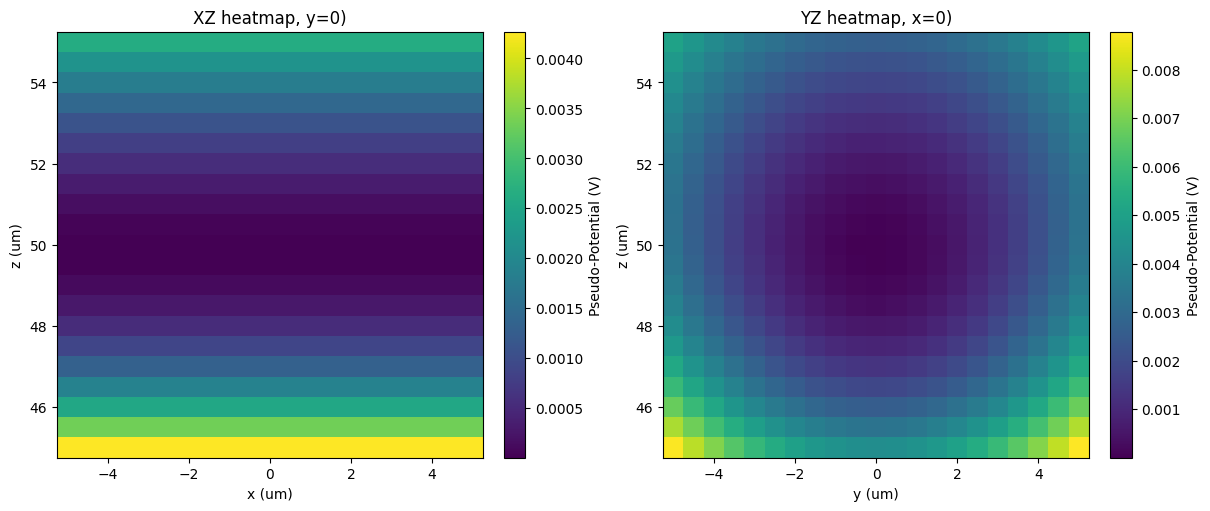

In [57]:
phi = pseudo_potential

# Choose central slices (or closest to 0 if available).
x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]

x_idx = int(np.argmin(np.abs(x_axis - 0.0))) if np.any(np.isfinite(x_axis)) else x.shape[0] // 2
y_idx = int(np.argmin(np.abs(y_axis - 0.0))) if np.any(np.isfinite(y_axis)) else y.shape[1] // 2

# xz slice at fixed y
X_xz = x[:, y_idx, :]
Z_xz = z[:, y_idx, :]
P_xz = phi[:, y_idx, :]

# yz slice at fixed x
Y_yz = y[x_idx, :, :]
Z_yz = z[x_idx, :, :]
P_yz = phi[x_idx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

hm1 = axes[0].pcolormesh(X_xz*1e6, Z_xz*1e6, P_xz, shading="auto", cmap="viridis")
axes[0].set_title(f"XZ heatmap, y={y_axis[y_idx]*1e6:.4g})")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("z (um)")
fig.colorbar(hm1, ax=axes[0], label="Pseudo-Potential (V)")

hm2 = axes[1].pcolormesh(Y_yz*1e6, Z_yz*1e6, P_yz, shading="auto", cmap="viridis")
axes[1].set_title(f"YZ heatmap, x={x_axis[x_idx]*1e6:.4g})")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("z (um)")
fig.colorbar(hm2, ax=axes[1], label="Pseudo-Potential (V)")

plt.show()

In [58]:
import h5py

output_filename = "rf_pseudo_potential.h5"

with h5py.File(output_filename, "w") as f:
    f.create_dataset("x", data=x)
    f.create_dataset("y", data=y)
    f.create_dataset("z", data=z)
    
    f.create_dataset("rf_pp", data=phi)

In [314]:
ion_height_index = np.argmin(pseudo_potential[0, 0, :])
ion_height_ansatz = z[0, 0, ion_height_index]  # Assuming ion is near the center of the trap
x_center_index = np.argmin(np.abs(x_axis - 0.0)) if np.any(np.isfinite(x_axis)) else x.shape[0] // 2
y_center_index = np.argmin(np.abs(y_axis - 0.0)) if np.any(np.isfinite(y_axis)) else y.shape[1] // 2

Text(0, 0.5, 'Pseudo-Potential (eV)')

Text(0, 0.5, 'Pseudo-Potential (eV)')

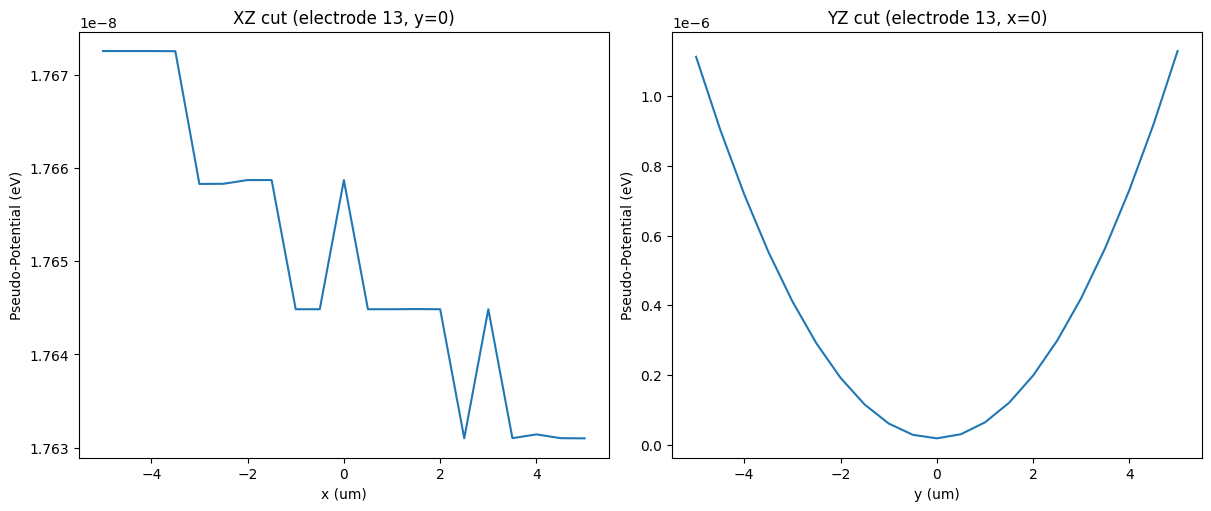

In [316]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axes[0].plot(x[:, y_center_index, ion_height_index]*1e6, pseudo_potential[:, y_center_index, ion_height_index])
axes[0].set_title(f"XZ cut (electrode {electrode}, y={y_axis[y_center_index]*1e6:.4g})")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("Pseudo-Potential (eV)")

axes[1].plot(y[x_center_index, :, ion_height_index]*1e6, pseudo_potential[x_center_index, :, ion_height_index])
axes[1].set_title(f"YZ cut (electrode {electrode}, x={x_axis[x_center_index]*1e6:.4g})")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("Pseudo-Potential (eV)")

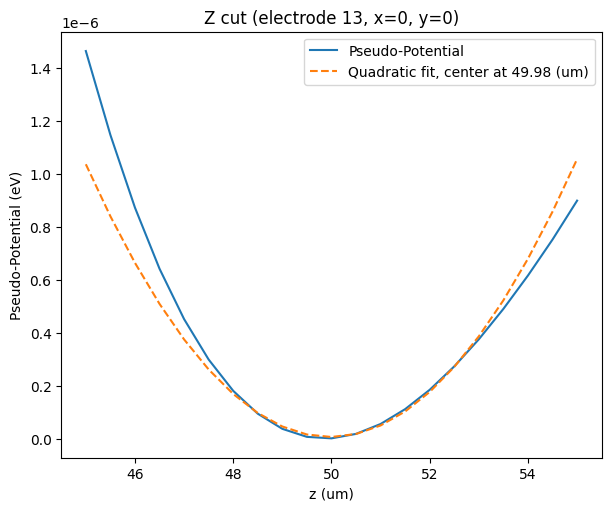

In [ ]:
phi_z = pseudo_potential[x_center_index, y_center_index, :]
z_vals = z[0, 0, :]
zmin = ion_height_ansatz
window = 2.5e-6  # 2.5 microns around the ion height
mask = np.abs(z_vals - zmin) <= window

coeff = np.polyfit(z_vals[mask], phi_z[mask], 2)
a, b, c = coeff

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.plot(z_vals*1e6, phi_z, label="Pseudo-Potential")
ax.plot(z_vals*1e6, a*z_vals**2 + b*z_vals + c, label=f"Quadratic fit, center at {-b/(2*a)*1e6:.4g} (um)", linestyle="--")
ax.set_title(f"Z cut (electrode {electrode}, x={x_axis[x_center_index]*1e6:.4g}, y={y_axis[y_center_index]*1e6:.4g})")
ax.set_xlabel("z (um)")
ax.set_ylabel("Pseudo-Potential (eV)")
ax.legend()
plt.show()

# Finding curvature at the minimum

By symmetry at the null position, we should only have $\phi_{pp} = \alpha (y^2 + z^2)$. Thus, we perform two fit along y and z to extract $\alpha$, with $\omega = \sqrt{2 \alpha/m}$.

In [16]:
from post_process import read_post_processed

x, y, z, potentials = read_post_processed(filename="rf_fine_sim_out.h5", electrode_list=[13])

phi_rf = -potentials[13]
x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

nx, ny, nz = phi_rf.shape
Ex = np.zeros_like(phi_rf)
Ey = np.zeros_like(phi_rf)
Ez = np.zeros_like(phi_rf)

if nx > 1:
    Ex = np.gradient(phi_rf, x_axis, axis=0, edge_order=1 if nx < 3 else 2)
if ny > 1:
    Ey = np.gradient(phi_rf, y_axis, axis=1, edge_order=1 if ny < 3 else 2)
if nz > 1:
    Ez = np.gradient(phi_rf, z_axis, axis=2, edge_order=1 if nz < 3 else 2)

pseudo_potential = pseudo_factor * (Ex**2 + Ey**2 + Ez**2) / 2

In [17]:
ion_height_ansatz = 49.98e-6
window = 2.5e-6  # radial selection radius in y-z plane

x_index = 0

# Build a rectangular local window first (for downstream grid plotting).
y_line = y[x_index, :, 0]
y_center_index = int(np.argmin(np.abs(y_line - 0.0)))
z_vals = z[x_index, y_center_index, :]
z_mask = np.abs(z_vals - ion_height_ansatz) <= window
if not np.any(z_mask):
    z_mask[np.argmin(np.abs(z_vals - ion_height_ansatz))] = True
iz = np.where(z_mask)[0]

z_center_index = int(np.argmin(np.abs(z_vals - ion_height_ansatz)))
z0 = z[x_index, y_center_index, z_center_index]
y_vals = y[x_index, :, z_center_index]
y_mask = np.abs(y_vals - 0.0) <= window
if not np.any(y_mask):
    y_mask[np.argmin(np.abs(y_vals - 0.0))] = True
iy = np.where(y_mask)[0]

# Windowed yz grid and pseudo-potential.
Y_abs = y[x_index][np.ix_(iy, iz)]
Z_abs = z[x_index][np.ix_(iy, iz)]
Pseudo_window = pseudo_potential[x_index][np.ix_(iy, iz)]

# Circular selection requested: y^2 + (z-ion_height_ansatz)^2 <= window^2
circle_mask = Y_abs**2 + (Z_abs - ion_height_ansatz)**2 <= window**2
if not np.any(circle_mask):
    dist2 = Y_abs**2 + (Z_abs - ion_height_ansatz)**2
    imin = np.unravel_index(np.argmin(dist2), dist2.shape)
    circle_mask[imin] = True

# Fit vectors.
Y = Y_abs[circle_mask].ravel()  # convert to microns for fitting
Z = Z_abs[circle_mask].ravel()-ion_height_ansatz  # convert to microns for fitting
Pseudo_phi = Pseudo_window[circle_mask].ravel()  # convert to microvolts for fitting

print(f"Selected points (circle): {len(Pseudo_phi)}")
print(f"Ny in window={len(iy)}, Nz in window={len(iz)}")

Selected points (circle): 1962
Ny in window=51, Nz in window=50


In [18]:
Pseudo_phi

array([2.8559660e-07, 2.7870965e-07, 2.7311899e-07, ..., 2.7322568e-07,
       2.7690584e-07, 2.8119118e-07], shape=(1962,), dtype=float32)

In [19]:
np.gradient(np.gradient(pseudo_potential[0, :, z_center_index], y_line, edge_order=2), y_line, edge_order=2)[y_center_index]/2

np.float32(45428.887)

In [20]:
A = np.column_stack([
    Y**2,
    Z**2,
    Y,
    Z,
    np.ones_like(Y)
])

coeff, *_ = np.linalg.lstsq(A, Pseudo_phi, rcond=None)

a, b, c, d, e = coeff

In [21]:
coeff, *_ = np.linalg.lstsq(A, Pseudo_phi, rcond=None)

a, b, c, d, e = coeff
ion_height_fit = -d/(2*b)+ ion_height_ansatz
omega_r = np.sqrt((a+b)*charge/mass)

In [22]:
print(coeff, ion_height_fit*1e6, -c/(2*a)*1e6, omega_r/(2*np.pi*1e6))

[ 4.57757208e+04  4.56567570e+04  1.66347720e-03 -1.14228988e-03
  3.07797259e-10] 49.99250953813426 -0.01816986352179776 0.07474308662641112


In [23]:
grad = np.array([c, d])
hessian = np.array([[2*a, 0], [0, 2*b]])

/var/folders/0t/t_n45mpd5hz903g9jhqvh76m0000gn/T/ipykernel_4496/901532962.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


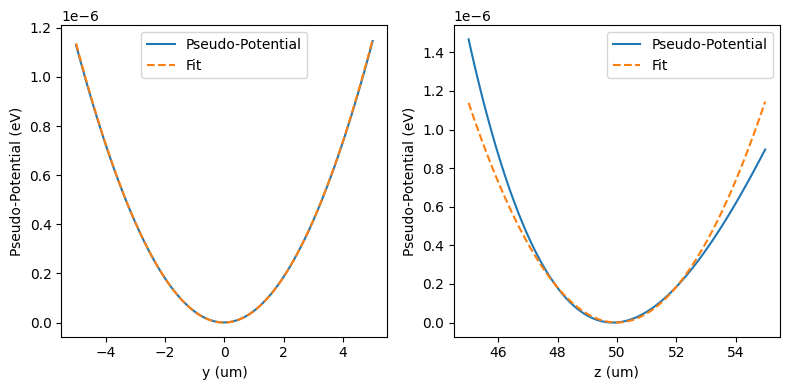

In [29]:
y_slice = y[0,:,z_center_index]
phi_y = pseudo_potential[0,:,z_center_index]

fig, axs = plt.subplots(1,2, figsize=(8, 4), constrained_layout=True)
ax = axs[0]
ax.plot(y_slice*1e6, phi_y, label="Pseudo-Potential")
ax.plot(y_slice*1e6, a*y_slice**2 + c*y_slice + b*(z0-ion_height_ansatz)**2 + d*(z0-ion_height_ansatz) + e, label="Fit", linestyle="--")
ax.set_xlabel("y (um)")
ax.set_ylabel("Pseudo-Potential (eV)")
ax.legend()

z_slice = z[0,y_center_index,:]
phi_z = pseudo_potential[0,y_center_index,:]

ax = axs[1]
ax.plot(z_slice*1e6, phi_z, label="Pseudo-Potential")
ax.plot(z_slice*1e6, b*(z_slice-ion_height_ansatz)**2 + d*(z_slice-ion_height_ansatz) + e, label="Fit", linestyle="--")
ax.set_xlabel("z (um)")
ax.set_ylabel("Pseudo-Potential (eV)")
ax.legend()
plt.tight_layout()
plt.savefig("rf_fit.pdf")
plt.show()

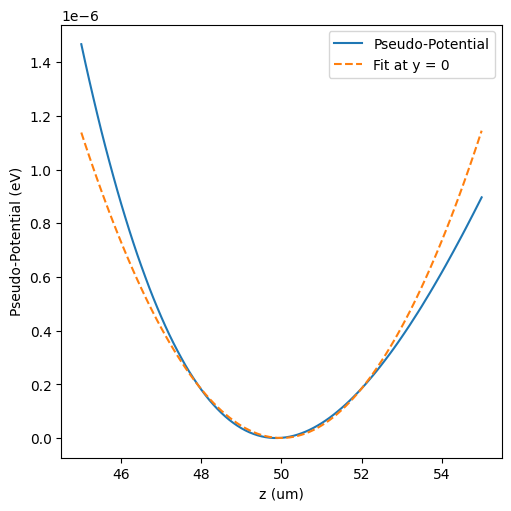

In [332]:
z_slice = z[0,y_center_index,:]
phi_z = pseudo_potential[0,y_center_index,:]

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.plot(z_slice*1e6, phi_z, label="Pseudo-Potential")
ax.plot(z_slice*1e6, b*(z_slice-ion_height_ansatz)**2 + d*(z_slice-ion_height_ansatz) + e, label="Fit at y = 0", linestyle="--")
ax.set_xlabel("z (um)")
ax.set_ylabel("Pseudo-Potential (eV)")
ax.legend()
plt.show()

In [351]:
from post_processing import read_post_processed

x, y, z, potentials = read_post_processed(filename="rf_fine_sim_out.h5", electrode_names=[13])

phi_rf = -potentials[13]
x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

nx, ny, nz = phi_rf.shape
Ex = np.zeros_like(phi_rf)
Ey = np.zeros_like(phi_rf)
Ez = np.zeros_like(phi_rf)

if nx > 1:
    Ex = np.gradient(phi_rf, x_axis, axis=0, edge_order=1 if nx < 3 else 2)
if ny > 1:
    Ey = np.gradient(phi_rf, y_axis, axis=1, edge_order=1 if ny < 3 else 2)
if nz > 1:
    Ez = np.gradient(phi_rf, z_axis, axis=2, edge_order=1 if nz < 3 else 2)

pseudo_potential = pseudo_factor * (Ex**2 + Ey**2 + Ez**2) / 2

In [366]:
from field_analysis import analyze_rf_pot

y_i = 0
z_i = 49.98e-6
x_index = 0

y_center_index = int(np.argmin(np.abs(y_axis - y_i)))
z_center_index = int(np.argmin(np.abs(z_axis - z_i)))

for n_points in [3, 5, 10, 20]:

    # Index window around each center
    half = max(0, n_points // 2)
    iy_start = max(0, y_center_index - half)
    iy_end = min(y.shape[1], y_center_index + half + 1)
    iz_start = max(0, z_center_index - half)
    iz_end = min(z.shape[2], z_center_index + half + 1)

    iy = np.arange(iy_start, iy_end)
    iz = np.arange(iz_start, iz_end)

    # Windowed yz grid and pseudo-potential
    Y_abs = y[x_index][np.ix_(iy, iz)]
    Z_abs = z[x_index][np.ix_(iy, iz)]
    Pseudo_window = pseudo_potential[x_index][np.ix_(iy, iz)]


    print(f"Selected points: Ny={len(iy)}, Nz={len(iz)}, total={len(Pseudo_window)}")
    print(f"Centers: y_idx={y_center_index}, z_idx={z_center_index}")

    coeff, grad, hessian, ion_height = analyze_rf_pot(Y_abs, Z_abs, Pseudo_window, z_i)

    print(ion_height, coeff)

Selected points: Ny=3, Nz=3, total=3
Centers: y_idx=50, z_idx=50
4.986902359550801e-05 [4.57907796e+04 4.62343335e+04 1.64012961e-03 1.02618402e-02
 5.91495482e-10]
Selected points: Ny=5, Nz=5, total=5
Centers: y_idx=50, z_idx=50
4.9867123504239125e-05 [4.59076210e+04 4.49417701e+04 1.63149163e-03 1.01457390e-02
 6.03904482e-10]
Selected points: Ny=11, Nz=11, total=11
Centers: y_idx=50, z_idx=50
4.987436078129475e-05 [4.57467615e+04 4.50517940e+04 1.65694238e-03 9.51847264e-03
 6.01176932e-10]
Selected points: Ny=21, Nz=21, total=21
Centers: y_idx=50, z_idx=50
4.9897042151652815e-05 [4.57217095e+04 4.50904380e+04 1.65805461e-03 7.48121144e-03
 6.37548139e-10]
